In [1]:
import torch
import torch.nn as nn

import numpy as np

from tqdm import tqdm
from torchvision.utils import save_image, make_grid


In [ ]:
dataset_path = './datasets/mnist'

DEVICE = torch.device( "cpu")
batch_size = 32

latent_dim = 15

lr = 1e-3
num_epochs = 100

In [3]:
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

mnist_transform = transforms.Compose([
    transforms.ToTensor(), # [0, 255] -> [0, 1]
])

kwargs = {'num_workers': 1, 'pin_memory': True} if torch.cuda.is_available() else {}

train_dataset = MNIST(dataset_path, train=True, transform=mnist_transform, download=True)
test_dataset = MNIST(dataset_path, train=False, transform=mnist_transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, **kwargs)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, **kwargs)

canais_img = train_dataset[0][0].shape[0]
input_channels = canais_img
print(f'Número de canais da imagem: {canais_img}')

# Acessando o primeiro item do dataset
amostra_x, rotulo = train_dataset[0]

# Extraindo dimensões
canais = amostra_x.shape[0]
altura = amostra_x.shape[1]
largura = amostra_x.shape[2]

print(f"--- Info da Amostra ---")
print(f"Dimensões da Imagem: {canais} canais x {altura}px x {largura}px")
print(f"Rótulo (Label): {rotulo}") 

100%|██████████| 9.91M/9.91M [00:02<00:00, 3.94MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 210kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 1.71MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.66MB/s]


Número de canais da imagem: 1
--- Info da Amostra ---
Dimensões da Imagem: 1 canais x 28px x 28px
Rótulo (Label): 5


In [59]:
class Encoder(nn.Module):
    def __init__(self, input_channels, latent_dim):
        super(Encoder, self).__init__()
        
        # 1. Camadas Convolucionais para extração de features espaciais
        self.conv_layers = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=3, stride=2, padding=1), # Saída: 14x14
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),            # Saída: 7x7
            nn.LeakyReLU(0.2),
            nn.Flatten() # Transforma o volume (64, 7, 7) em um vetor único
        )
        
        # Precisamos calcular o tamanho da entrada após o flatten
        # Para uma imagem 28x28 com 2 strides, chegamos a 7x7. 64 canais * 7 * 7 = 3136
        flat_features = 64 * 7 * 7 
        
        # 2. Camadas Lineares para os parâmetros da Gaussiana
        self.fc_mean = nn.Linear(flat_features, latent_dim)
        self.fc_logvar = nn.Linear(flat_features, latent_dim)

    def forward(self, x):
        # x deve ter o shape [Batch, Channels, Height, Width]
        h_ = self.conv_layers(x)
        
        mean = self.fc_mean(h_)
        logvar = self.fc_logvar(h_)
        
        return mean, logvar

In [60]:
class Decoder(nn.Module):
    def __init__(self, latent_dim, output_channels):
        super(Decoder, self).__init__()
        
        # 1. Expandir o vetor latente de volta para a dimensão do último mapa de features
        # No Encoder era (64, 7, 7), então flat_features = 3136
        self.fc_upsample = nn.Linear(latent_dim, 64 * 7 * 7)
        
        # 2. Camadas de Convolução Transposta (Upsampling)
        self.deconv_layers = nn.Sequential(
            # Entrada: [Batch, 64, 7, 7]
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), 
            # Saída: [Batch, 32, 14, 14]
            nn.LeakyReLU(0.2),
            
            nn.ConvTranspose2d(32, output_channels, kernel_size=3, stride=2, padding=1, output_padding=1),
            # Saída: [Batch, output_channels, 28, 28]
            nn.Sigmoid() # Garante que os pixels estejam entre 0 e 1
        )

    def forward(self, z):
        # Transforma o vetor latente em um vetor "largo"
        h = self.fc_upsample(z)
        
        # Faz o "Reshape" para o formato de volume (Batch, Channels, Height, Width)
        # Isso é o inverso do Flatten()
        h = h.view(-1, 64, 7, 7)
        
        # Passa pelas camadas de expansão espacial
        y_hat = self.deconv_layers(h)
        
        return y_hat

In [61]:
class Model(nn.Module):
    def __init__(self, Encoder, Decoder):
        super(Model, self).__init__()
        self.Encoder = Encoder
        self.Decoder = Decoder
    
    def reparameterize(self, mean, logvar):
        dp = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(dp).to(DEVICE)
        z = mean + dp * epsilon
        return z
    
    def forward(self, x):
        mean, logvar = self.Encoder(x)
        z = self.reparameterize(mean, logvar)
        y_hat = self.Decoder(z)
        return y_hat, mean, logvar
    

In [ ]:
encoder = Encoder(input_channels, latent_dim)
decoder = Decoder(latent_dim, input_channels)
import torchsummary as summary
model = Model(encoder, decoder).to(DEVICE)

summary.summary(model, input_size=(input_channels, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 14, 14]             320
         LeakyReLU-2           [-1, 32, 14, 14]               0
            Conv2d-3             [-1, 64, 7, 7]          18,496
         LeakyReLU-4             [-1, 64, 7, 7]               0
           Flatten-5                 [-1, 3136]               0
            Linear-6                   [-1, 15]          47,055
            Linear-7                   [-1, 15]          47,055
           Encoder-8       [[-1, 15], [-1, 15]]               0
            Linear-9                 [-1, 3136]          50,176
  ConvTranspose2d-10           [-1, 32, 14, 14]          18,464
        LeakyReLU-11           [-1, 32, 14, 14]               0
  ConvTranspose2d-12            [-1, 1, 28, 28]             289
          Sigmoid-13            [-1, 1, 28, 28]               0
          Decoder-14            [-1, 1,

In [63]:
from torch.optim import Adam

# BCE_loss = nn.BCELoss()
# nn.functional.binary_cross_entropy(y_hat, x, reduction='sum')

def loss_(x, y_hat, mean, logvar):
    reproduction_loss = -torch.sum(x * torch.log(y_hat + 1e-10) + (1 - x) * torch.log(1 - y_hat + 1e-10))
    DKL = -0.5 * torch.sum(1 + logvar - mean.pow(2) - logvar.exp())
    return reproduction_loss + DKL

optimizer = Adam(model.parameters(), lr=lr)

In [ ]:
print("Starting training VAE...")
model.train()

for epoch in range(num_epochs):
    overall_loss = 0
    for batch_idx, (x, _) in enumerate(tqdm(train_loader)):
        x = x.view(-1, input_channels, altura, largura).to(DEVICE) # Garantindo que x tenha o formato correto para o Encoder

        optimizer.zero_grad()

        y_hat, mean, logvar = model(x, y)

        # Printando a média e o logvar do primeiro item do batch
        if batch_idx == 0: # Printa apenas no primeiro batch para não inundar a tela
            print(f"Média (primeiros 5 valores do vetor): {mean[0][:5].detach().cpu().numpy()}")
            print(f"LogVar (primeiros 5 valores do vetor): {logvar[0][:5].detach().cpu().numpy()}")

        loss = loss_(x, y_hat, mean, logvar)

        overall_loss += loss.item()
        loss.backward()
        optimizer.step()
    print("\tOverall Loss:", overall_loss, "\t(batch_idx+1): ", batch_idx+1, "\tBatch Size: ", batch_size)    
    print("\tEpoch", epoch + 1, "complete!", "\tAverage Loss: ", overall_loss / ((batch_idx+1)*batch_size))
print("Finish!!")

Starting training VAE...


  0%|          | 0/1875 [00:00<?, ?it/s]

Média (primeiros 5 valores do vetor): [-0.07543312  0.03986551  0.00905668  0.04255811 -0.03097945]
LogVar (primeiros 5 valores do vetor): [ 0.02304479 -0.07297256 -0.11627015  0.0151965   0.05225863]


100%|██████████| 1875/1875 [00:34<00:00, 53.82it/s]


	Overall Loss: 8044958.855224609 	(batch_idx+1):  1875 	Batch Size:  32
	Epoch 1 complete! 	Average Loss:  134.08264758707682


...

	Overall Loss: 5971493.259277344 	(batch_idx+1):  1875 	Batch Size:  32
	Epoch 99 complete! 	Average Loss:  99.52488765462239


  0%|          | 4/1875 [00:00<00:54, 34.08it/s]

Média (primeiros 5 valores do vetor): [-1.0990784 -0.8676492 -2.849609  -1.1444013 -0.579491 ]
LogVar (primeiros 5 valores do vetor): [-3.5930924 -2.3133173 -2.6174822 -2.355555  -3.6464782]


100%|██████████| 1875/1875 [00:48<00:00, 38.43it/s]

	Overall Loss: 5971671.954589844 	(batch_idx+1):  1875 	Batch Size:  32
	Epoch 100 complete! 	Average Loss:  99.52786590983072
Finish!!


In [65]:

import matplotlib.pyplot as plt

In [66]:
model.eval()

with torch.no_grad():
    for batch_idx, (x, _) in enumerate(tqdm(test_loader)):
        # x = x.view(batch_size, x_dim).to(DEVICE)
        x = x.view(-1, input_channels, altura, largura).to(DEVICE)
        y_hat, _, _ = model(x)
        


        break

  0%|          | 0/313 [00:00<?, ?it/s]


In [67]:
import numpy as np
import matplotlib.pyplot as plt

def show_image(x, idx):
    # 1. Debug: Printar o shape original (Batch, Canais, Altura, Largura)
    print(f"Shape original recebido: {x.shape}")
    
    x = x.detach().cpu()
    
    x = x.permute(0, 2, 3, 1)
    print(f"Shape após permute (Batch): {x.shape}")
    
    # 3. Configuração do Grid
    grid_size = int(np.sqrt(idx))
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
    
    # Caso idx seja 1, o subplots não retorna um array, então forçamos a lista
    if idx == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i in range(idx):
        if i < len(x):
            # Para 3 canais (RGB), imshow detecta automaticamente se o canal estiver no final
            # Se for 1 canal após o permute, o Matplotlib ainda pode precisar de cmap='gray'
            img_to_show = x[i].numpy()
            
            # Se a última dimensão for 1 (Grayscale), o imshow precisa dela 'achatada'
            if img_to_show.shape[-1] == 1:
                img_to_show = img_to_show.squeeze(-1)
                axes[i].imshow(img_to_show, cmap='gray')
            else:
                axes[i].imshow(img_to_show)
                
            axes[i].axis('off')
        else:
            axes[i].axis('off')

    plt.tight_layout()
    plt.show()

Shape original recebido: torch.Size([32, 1, 28, 28])
Shape após permute (Batch): torch.Size([32, 28, 28, 1])


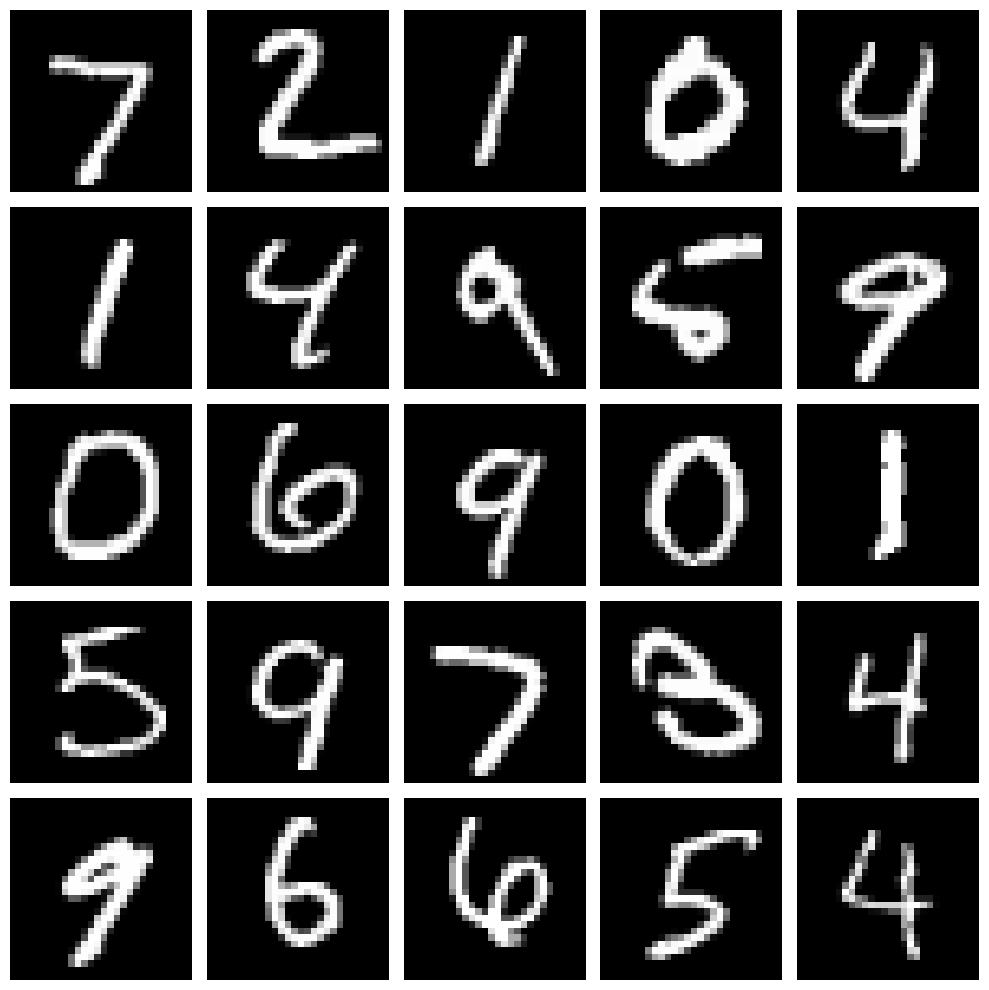

In [68]:
show_image(x, idx=25)

Shape original recebido: torch.Size([32, 1, 28, 28])
Shape após permute (Batch): torch.Size([32, 28, 28, 1])


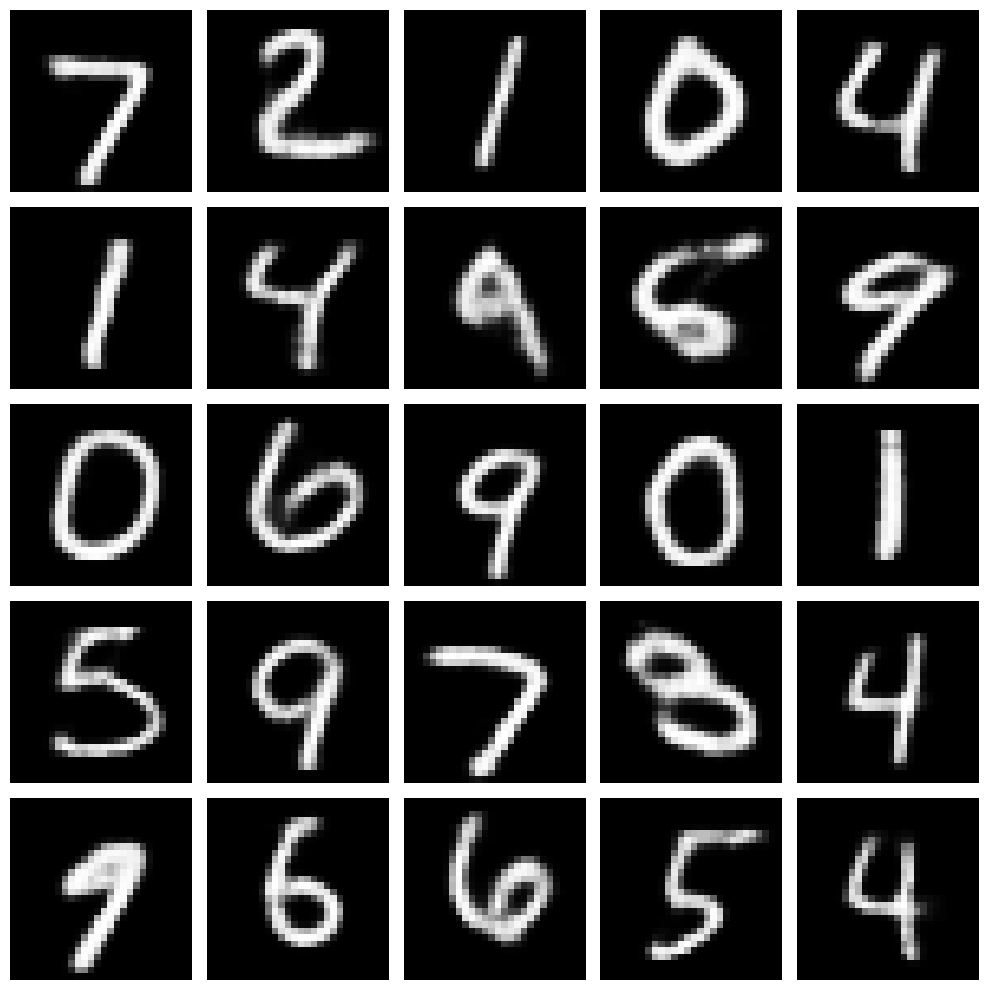

In [69]:
show_image(y_hat, idx=25)

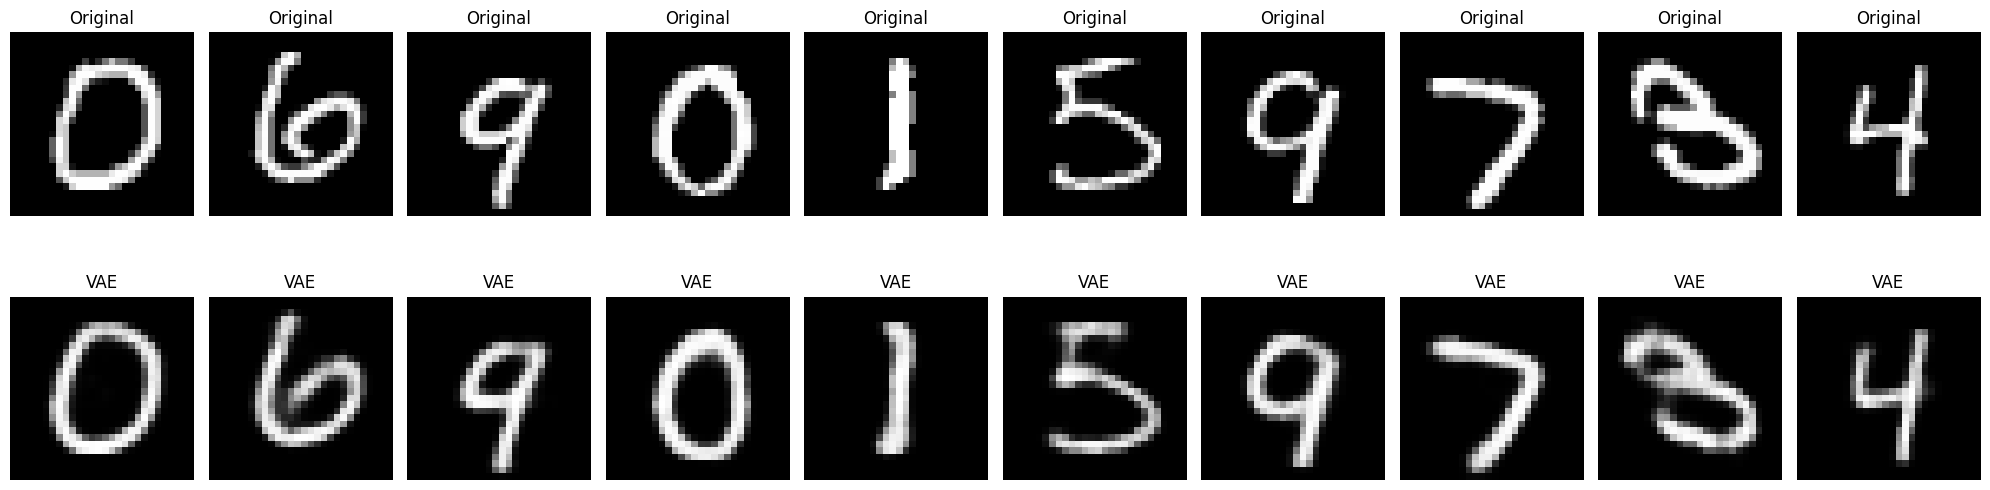

In [71]:
import matplotlib.pyplot as plt
import torch

model.eval()
with torch.no_grad():
    for x, _ in test_loader:
        # x já vem do loader como [B, 3, H, W]
        x = x.to(DEVICE)
        y_hat, _, _ = model(x)
        break

n = 10 
plt.figure(figsize=(20, 6)) # Aumentei um pouco a altura para caber melhor os títulos

for i in range(n):
    # --- Imagem Original ---
    ax = plt.subplot(2, n, i + 1)
    
    # Prepara a imagem: move canais para o final [3, 28, 28] -> [28, 28, 3]
    img_original = x[i+10].cpu().permute(1, 2, 0)
    
    plt.imshow(img_original, cmap='gray') # Usando cmap='gray' para garantir que as imagens em escala de cinza sejam exibidas corretamente
    plt.title("Original")
    ax.axis('off')

    # --- Imagem Reconstruída ---
    ax = plt.subplot(2, n, i + 1 + n)
    
    # Mesmo processo para a reconstrução
    img_reconstruida = y_hat[i+10].cpu().permute(1, 2, 0)
    
    plt.imshow(img_reconstruida, cmap='gray') # Usando cmap='gray' para garantir que as imagens em escala de cinza sejam exibidas corretamente
    plt.title("VAE")
    ax.axis('off')

plt.tight_layout()
plt.show()